# 03a · Normal & Uniform Dağılımları
**Probability Lab** · Continuous Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Veri biliminin en temel iki sürekli dağılımını anlayacağız:  
> **Normal** — doğanın her yerinde karşılaşılan çan eğrisi,  
> **Uniform** — tamamen belirsizliği modelleyen düz çizgi.  
> QQ-Plot, Z-score, normallik testleri ve CLT bağlantısı da bu notebook'ta.

**Önkoşul:** PMF / PDF / CDF kavramları (Notebook 01)  
**Veri:** `SOCR-HeightWeight.csv` — 25.000 kişilik boy ve kilo ölçümleri  
**Kullanılan araçlar:** Python (scipy, matplotlib, seaborn), R (base), SQL (DuckDB)

---
## 1 · Normal Dağılım

### 1.1 Neden Her Yerde Normal?

Doğada bağımsız birçok küçük faktörün toplamı olan ölçümler Normal dağılır:  
Boy = genetik + beslenme + çevre + ... (onlarca bağımsız etken toplamı)

Bu, Merkezi Limit Teoremi'nin (CLT) bir sonucudur —  
**bağımsız rastgele değişkenlerin toplamı, her zaman Normal'e yaklaşır.**

### 1.2 Tanım ve PDF

$X \sim N(\mu, \sigma^2)$ demek:
- $\mu$ = ortalama (dağılımın merkezi)
- $\sigma$ = standart sapma (dağılımın yayılımı)
- $\sigma^2$ = varyans

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \quad x \in (-\infty, +\infty)$$

Formülün parçaları:

| Parça | Rolü |
|---|---|
| $\frac{1}{\sigma\sqrt{2\pi}}$ | Normalleştirici — toplam alan 1 olsun diye |
| $\exp(-(x-\mu)^2/2\sigma^2)$ | Çan şeklinin matematiksel ifadesi |
| $\sigma$ paydada | $\sigma$ büyüdükçe eğri yatıklaşır (yayılır) |

### 1.3 Standart Normal: Z-Dönüşümü

$\mu = 0$, $\sigma = 1$ olan özel duruma **Standart Normal** denir: $Z \sim N(0, 1)$

**Herhangi bir Normal'i Standart Normal'e dönüştür:**

$$Z = \frac{X - \mu}{\sigma}$$

Bu dönüşüm neden işe yarar?  
- Farklı ölçek/birimden ölçümleri karşılaştırılabilir hale getirir
- Tek bir tablo (Z-tablosu) tüm Normal dağılımlar için yeterli
- ML'de **feature normalization**'ın matematiksel temelidir

### 1.4 68–95–99.7 Kuralı (Ampirik Kural)

| Aralık | Olasılık | Ne anlama geliyor? |
|---|---|---|
| $\mu \pm 1\sigma$ | **%68.27** | Her 100 gözlemden 68'i burada |
| $\mu \pm 2\sigma$ | **%95.45** | Her 100 gözlemden 95'i burada |
| $\mu \pm 3\sigma$ | **%99.73** | Her 100 gözlemden ~100'ü burada |

Bu kural ezberlenmeye değer — sürekli kullanacaksın.

![image](data/norm-dist.webp)

### 1.5 Beklenti ve Varyans

$$E[X] = \mu \qquad \text{Var}(X) = \sigma^2 \qquad \text{Std}(X) = \sigma$$

> **Normal dağılım tamamen $\mu$ ve $\sigma$ ile belirlenir.**  
> İki parametre → dağılımın her şeyini biliyoruz.

---
## 2 · Normallik Testi: QQ-Plot ve İstatistiksel Testler

Gerçek veri Normal mi? Bunu anlamak için iki araç:

### 2.1 QQ-Plot (Quantile-Quantile Plot)

**Sezgi:** Eğer veri gerçekten Normal dağılıyorsa,  
gerçek veri yüzdelikleri ile teorik Normal yüzdelikleri **bir doğru üzerinde olmalı**.

**Nasıl okunur?**
- Noktalar $y = x$ doğrusu üzerinde → veri Normal
- Başta/sonda **yukarı kıvrılma** → sağ kuyruk çok ağır (heavy-tailed)
- Başta/sonda **aşağı kıvrılma** → sol kuyruk çok ağır
- **S şekli** → veri iki mod içeriyor (bimodal)

### 2.2 İstatistiksel Testler

| Test | Fonksiyon | Güçlü yanı |
|---|---|---|
| **Shapiro-Wilk** | `stats.shapiro(x)` | Küçük örneklem (n < 5000) için en güçlü |
| **Kolmogorov-Smirnov** | `stats.kstest(x, 'norm')` | Büyük örneklem; parametreleri bil |
| **D'Agostino-Pearson** | `stats.normaltest(x)` | Çarpıklık + basıklık tabanlı |

**Dikkat:** Büyük $n$'de tüm testler küçük sapmada bile p < 0.05 verir.  
$n > 1000$'de QQ-Plot daha güvenilir rehberdir.

### 2.3 Çarpıklık (Skewness) ve Basıklık (Kurtosis)

| Özellik | Normal değeri | Yorumu |
|---|---|---|
| Çarpıklık | 0 | Sıfırdan farklıysa asimetrik |
| Basıklık (excess) | 0 | >0 → sivri tepe (heavy-tail), <0 → basık tepe |

---
## 3 · Uniform Dağılım

### 3.1 Tanım

$X \sim \text{Uniform}(a, b)$ demek: $a$ ile $b$ arasındaki **her değer eşit olasılıklı**.

$$f(x) = \frac{1}{b - a}, \quad a \leq x \leq b \qquad (\text{sıfır, dışarıda})$$

$$E[X] = \frac{a + b}{2} \qquad \text{Var}(X) = \frac{(b-a)^2}{12}$$

### 3.2 Neden Önemli?

1. **Simülasyon temeli:** Bilgisayarlar önce Uniform üretir, sonra dönüştürür
2. **Bayesian prior:** Hiçbir şey bilmiyorsak → Uniform prior ("her değer eşit olası")
3. **Rastgelelik testi:** Gerçek rassal süreçlerin temel dağılımı
4. **CLT başlangıcı:** Uniform toplamı → Normal'e yaklaşır (CLT'nin en saf örneği)

### 3.3 Kesikli Uniform

Bir zar $\sim \text{Uniform}(\{1,2,3,4,5,6\})$:  
Her yüz olasılığı $1/6$ → Kesikli Uniform PMF.

### 3.4 CDF

$$F(x) = \begin{cases} 0 & x < a \\ \frac{x-a}{b-a} & a \leq x \leq b \\ 1 & x > b \end{cases}$$

CDF doğrusal — bir doğru parçası. Bu, Uniform'un en ayırt edici görsel özelliğidir.

---
## 4 · Uniform → Normal: CLT'nin En Saf Örneği

Uniform, Normal'den ne kadar farklı görünürse görünsün —  
**$n$ tane Uniform'u toplarsan, toplam Normal'e yaklaşır.**

$$X_1, X_2, \ldots, X_n \overset{\text{iid}}{\sim} \text{Uniform}(0,1) \implies \frac{\sum X_i - n/2}{\sqrt{n/12}} \xrightarrow{d} N(0,1)$$

Hızlı yaklaşım: $n = 12$ Uniform(0,1) toplam → ortalama ve std'si Normal'e çok yakın.  
Bu, **Box-Muller öncesi** Normal sayı üretmenin klasik yoluydu.

| Kavram | Kesikli karşılığı | Sürekli karşılığı |
|---|---|---|
| "Tüm değerler eşit olası" | Zar / Uniform PMF | Uniform $(a,b)$ |
| "Doğal süreçlerin toplamı" | Binomial → Normal | Uniform toplamı → Normal |
| Limit dağılımı | Normal | Normal |

---
# 🐍 Python Uygulaması

5 adımda:
1. **Normal PDF/CDF** — $\mu$ ve $\sigma$ parametrelerinin görsel etkisi
2. **SOCR Height verisi** — gerçek boy verisiyle Normal fit, 68-95-99.7 kuralı
3. **QQ-Plot + Normallik testleri** — boy ve kilo hangi dağılıma uyuyor?
4. **Uniform dağılım** — PDF, CDF, CLT bağlantısı
5. **Z-score** — standardizasyon ve skor karşılaştırması

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12

DATA_PATH = 'data'

print('Hazir ✓')


Hazir ✓


---
### 📈 Python 1 — Normal PDF ve CDF: Parametreler Değişince Ne Olur?

**Ne yapıyoruz?**  
$\mu$ ve $\sigma$ parametrelerini değiştirerek Normal'in şeklini inceliyoruz.

**Mantık:**
- `stats.norm(loc=mu, scale=sigma)` → Normal dağılım nesnesi  
  `loc` = $\mu$ (ortalama), `scale` = $\sigma$ (standart sapma)
- `.pdf(x)` → yoğunluk değeri (tek noktada olasılık değil!)
- `.cdf(x)` → $P(X \leq x)$
- `fill_between` → 68-95-99.7 alanlarını gölgelemek için

**Gözlemlenecekler:**
- $\mu$ değişince eğri **yatay kayar** (şekil değişmez)
- $\sigma$ değişince eğri **genişler veya daralır** (tepe yüksekliği de değişir!)
- Her dağılımda toplam alan = 1 (tepe yüksekliği ile genişlik ters orantılı)

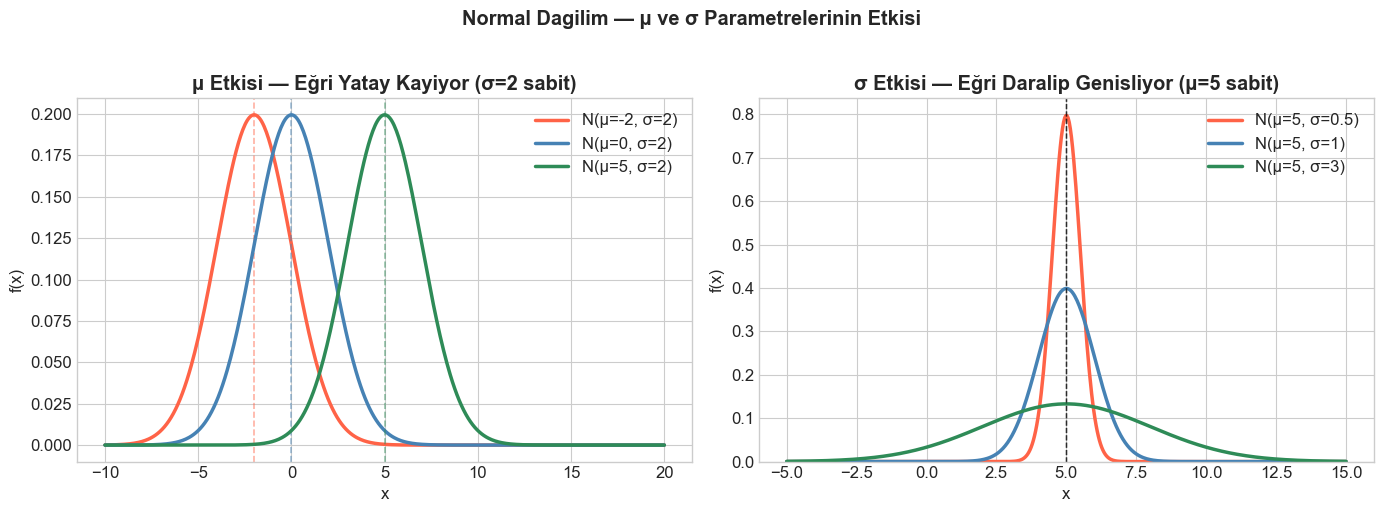

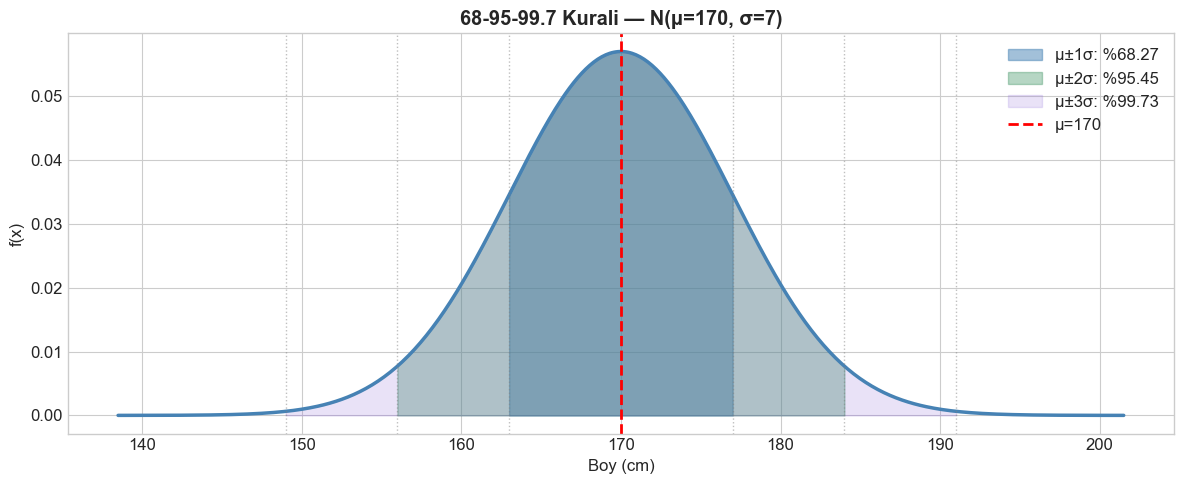

=== 68-95-99.7 Sayisal Dogrulama ===
P(μ-1σ < X < μ+1σ) = 0.6827 = %68.27
P(μ-2σ < X < μ+2σ) = 0.9545 = %95.45
P(μ-3σ < X < μ+3σ) = 0.9973 = %99.73

=== Temel CDF Sorulari ===
P(X < 170)         = 0.5000  (mu noktasi: 0.5 olmali)
P(X > 184)         = 0.0228  (μ+2σ ustu)
P(163 < X < 177)   = 0.6827  (μ±1σ)
%99 yuzdelik boy   = 186.3 cm


In [2]:
x = np.linspace(-10, 20, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Sol: mu'nun etkisi (sigma sabit) ────────────────────────────────────────
ax = axes[0]
sigma_sabit = 2
for mu, renk in [(-2,'tomato'), (0,'steelblue'), (5,'seagreen')]:
    dist  = stats.norm(loc=mu, scale=sigma_sabit)
    y     = dist.pdf(x)
    ax.plot(x, y, color=renk, linewidth=2.5,
            label=f'N(μ={mu}, σ={sigma_sabit})')
    ax.axvline(mu, color=renk, linestyle='--', alpha=0.5, linewidth=1.2)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('μ Etkisi — Eğri Yatay Kayiyor (σ=2 sabit)', fontweight='bold')
ax.legend()

# ─── Sag: sigma'nin etkisi (mu sabit) ────────────────────────────────────────
ax = axes[1]
mu_sabit = 5
x2 = np.linspace(-5, 15, 500)
for sigma, renk in [(0.5,'tomato'), (1,'steelblue'), (3,'seagreen')]:
    dist = stats.norm(loc=mu_sabit, scale=sigma)
    y    = dist.pdf(x2)
    ax.plot(x2, y, color=renk, linewidth=2.5,
            label=f'N(μ={mu_sabit}, σ={sigma})')
    ax.axvline(mu_sabit, color='black', linestyle='--', alpha=0.4, linewidth=1)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('σ Etkisi — Eğri Daralip Genisliyor (μ=5 sabit)', fontweight='bold')
ax.legend()
ax.set_ylim(bottom=0)

plt.suptitle('Normal Dagilim — μ ve σ Parametrelerinin Etkisi', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── 68-95-99.7 kurali gorsel kanitlama ──────────────────────────────────────
mu, sigma = 170, 7
dist = stats.norm(loc=mu, scale=sigma)
x3   = np.linspace(mu - 4.5*sigma, mu + 4.5*sigma, 500)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x3, dist.pdf(x3), 'steelblue', linewidth=2.5)

katlar_renk = [(1,'steelblue',0.5), (2,'seagreen',0.35), (3,'mediumpurple',0.2)]
for k, renk, alpha in katlar_renk:
    x_fill = np.linspace(mu - k*sigma, mu + k*sigma, 300)
    alan   = dist.cdf(mu + k*sigma) - dist.cdf(mu - k*sigma)
    ax.fill_between(x_fill, dist.pdf(x_fill), alpha=alpha, color=renk,
                    label=f'μ±{k}σ: %{alan*100:.2f}')

ax.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'μ={mu}')
for k in [1, 2, 3]:
    for yon in [-1, 1]:
        ax.axvline(mu + yon*k*sigma, color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax.set_xlabel('Boy (cm)')
ax.set_ylabel('f(x)')
ax.set_title(f'68-95-99.7 Kurali — N(μ={mu}, σ={sigma})', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('=== 68-95-99.7 Sayisal Dogrulama ===')
for k in [1, 2, 3]:
    p = dist.cdf(mu + k*sigma) - dist.cdf(mu - k*sigma)
    print(f'P(μ-{k}σ < X < μ+{k}σ) = {p:.4f} = %{p*100:.2f}')

print()
print('=== Temel CDF Sorulari ===')
print(f'P(X < 170)         = {dist.cdf(170):.4f}  (mu noktasi: 0.5 olmali)')
print(f'P(X > 184)         = {1-dist.cdf(184):.4f}  (μ+2σ ustu)')
print(f'P(163 < X < 177)   = {dist.cdf(177)-dist.cdf(163):.4f}  (μ±1σ)')
print(f'%99 yuzdelik boy   = {dist.ppf(0.99):.1f} cm')


---
### 🏃 Python 2 — SOCR Height Verisi: Gerçek Boy Dağılımı

**Veri:** `SOCR-HeightWeight.csv` — 25.000 kişilik boy (inç) ve kilo (pound) verisi  
Kaynak: SOCR (Statistics Online Computational Resource), Michigan Üniversitesi

**Ne yapıyoruz?**
1. İnç → cm, pound → kg dönüşümü
2. MLE ile $\hat{\mu}$ ve $\hat{\sigma}$ tahmini
3. Gözlemlenen dağılım ile Normal fit karşılaştırması
4. 68-95-99.7 kuralını gerçek veriye uygulama

**Mantık:**
- `stats.norm.fit(data)` → MLE ile $\hat{\mu}$ ve $\hat{\sigma}$ tahmin et  
  Normal için MLE: $\hat{\mu} = \bar{x}$, $\hat{\sigma} = s$ (örnek std sapma)
- `stats.norm.pdf(x, mu, sigma)` → fit edilmiş Normal eğrisini çiz

Yuklendi: 25,000 satir
       height_cm  weight_kg
count   25000.00   25000.00
mean      172.70      57.64
std         4.83       5.29
min       153.11      35.39
25%       169.43      54.12
50%       172.71      57.68
75%       175.95      61.19
max       190.89      77.53

Boy  fit: N(μ=172.70 cm, σ=4.83 cm)
Kilo fit: N(μ=57.64 kg, σ=5.29 kg)


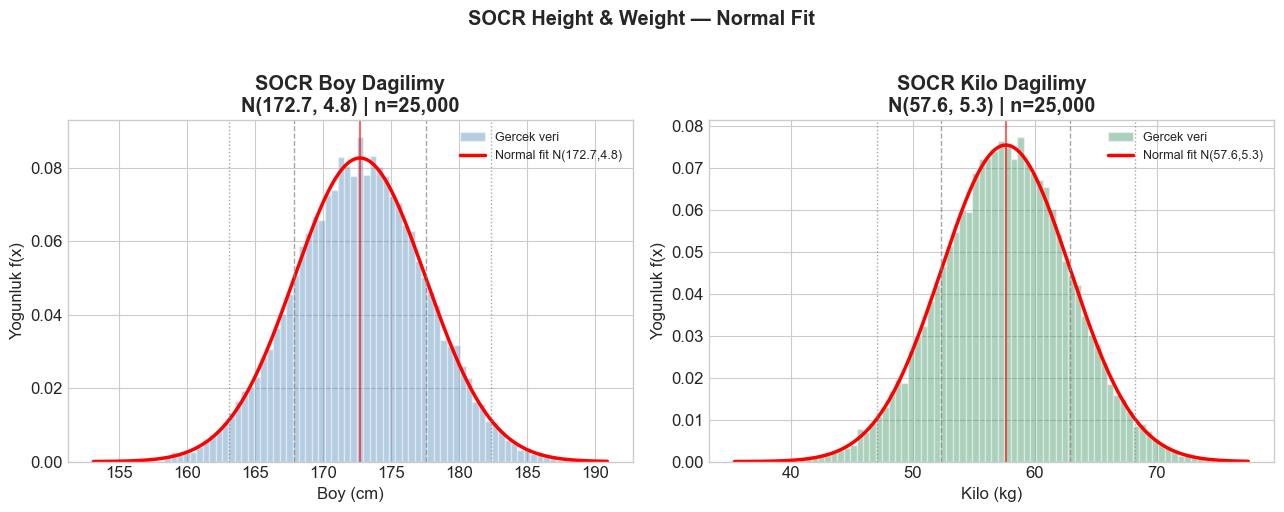

=== 68-95-99.7 Kurali — Gercek Veride Dogrulama ===
μ±1σ (167.9-177.5 cm): Gercek=0.6836  Teorik=0.6827  Fark=0.0009
μ±2σ (163.0-182.4 cm): Gercek=0.9546  Teorik=0.9545  Fark=0.0001
μ±3σ (158.2-187.2 cm): Gercek=0.9980  Teorik=0.9973  Fark=0.0007


In [10]:
df = pd.read_csv(f'{DATA_PATH}/SOCR-HeightWeight.csv')

# Birim donusumu
df['height_cm'] = df['Height(Inches)'] * 2.54
df['weight_kg'] = df['Weight(Pounds)'] * 0.453592

print(f'Yuklendi: {len(df):,} satir')
print(df[['height_cm','weight_kg']].describe().round(2))

# ─── MLE parametreleri ────────────────────────────────────────────────────────
# stats.norm.fit() → (mu_hat, sigma_hat) dondurur — bu MLE tahmindir
# Normal icin MLE: mu_hat = xbar, sigma_hat = orneklem std sapma
mu_boy,  sigma_boy  = stats.norm.fit(df['height_cm'])
mu_kilo, sigma_kilo = stats.norm.fit(df['weight_kg'])

print(f'\nBoy  fit: N(μ={mu_boy:.2f} cm, σ={sigma_boy:.2f} cm)')
print(f'Kilo fit: N(μ={mu_kilo:.2f} kg, σ={sigma_kilo:.2f} kg)')

# ─── Grafik: histogram + Normal fit ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, kolon, mu, sigma, birim, renk in [
    (axes[0], 'height_cm', mu_boy,  sigma_boy,  'cm', 'steelblue'),
    (axes[1], 'weight_kg', mu_kilo, sigma_kilo, 'kg', 'seagreen')
]:
    veri = df[kolon]
    ax.hist(veri, bins=80, density=True, color=renk, alpha=0.4,
            edgecolor='white', label='Gercek veri')

    x_r = np.linspace(veri.min(), veri.max(), 400)
    ax.plot(x_r, stats.norm.pdf(x_r, mu, sigma),
            'red', linewidth=2.5, label=f'Normal fit N({mu:.1f},{sigma:.1f})')

    # mu +/- 1, 2, 3 sigma cizgileri
    for k, ls in [(1,'--'),(2,':')]:
        ax.axvline(mu - k*sigma, color='gray', linestyle=ls, alpha=0.7, linewidth=1)
        ax.axvline(mu + k*sigma, color='gray', linestyle=ls, alpha=0.7, linewidth=1)
    ax.axvline(mu, color='red', linestyle='-', alpha=0.6, linewidth=1.5)

    ad    = 'Boy' if 'height' in kolon else 'Kilo'
    ax.set_xlabel(f'{ad} ({birim})')
    ax.set_ylabel('Yogunluk f(x)')
    ax.set_title(
        f'SOCR {ad} Dagilimy\nN({mu:.1f}, {sigma:.1f}) | n=25,000',
        fontweight='bold'
    )
    ax.legend(fontsize=9)

plt.suptitle('SOCR Height & Weight — Normal Fit', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── 68-95-99.7 gercek veride dogrulama ─────────────────────────────────────
print('=== 68-95-99.7 Kurali — Gercek Veride Dogrulama ===')
boy = df['height_cm']
for k in [1, 2, 3]:
    alt, ust   = mu_boy - k*sigma_boy, mu_boy + k*sigma_boy
    gercek_oran = ((boy >= alt) & (boy <= ust)).mean()
    teorik_oran = stats.norm.cdf(ust, mu_boy, sigma_boy) - stats.norm.cdf(alt, mu_boy, sigma_boy)
    print(
        f'μ±{k}σ ({alt:.1f}-{ust:.1f} cm): '
        f'Gercek={gercek_oran:.4f}  Teorik={teorik_oran:.4f}  '
        f'Fark={abs(gercek_oran-teorik_oran):.4f}'
    )


---
### 🔬 Python 3 — QQ-Plot ve Normallik Testleri

**Ne yapıyoruz?**  
Boy ve kilo verisinin Normal dağılıma uyup uymadığını QQ-Plot ve istatistiksel testlerle inceliyoruz.

**QQ-Plot mantığı:**  
`scipy.stats.probplot(data, dist='norm', plot=ax)` şunu yapar:
1. Veriyi küçükten büyüğe sırala
2. Her gözlem için teorik Normal yüzdeliğini hesapla
3. `(teorik yüzdelik, gözlemlenen değer)` çiftlerini çiz
4. Noktalar doğru üzerindeyse → veri Normal

**Normallik testleri:**
- `stats.shapiro(x)` → H₀: veri Normal. p > 0.05 ise H₀ reddedilmez
- `stats.normaltest(x)` → D'Agostino-Pearson: çarpıklık + basıklık tabanlı
- `stats.skew(x)` → Çarpıklık: 0'a yakın ise simetrik
- `stats.kurtosis(x)` → Basıklık (excess): 0'a yakın ise Normal benzeri

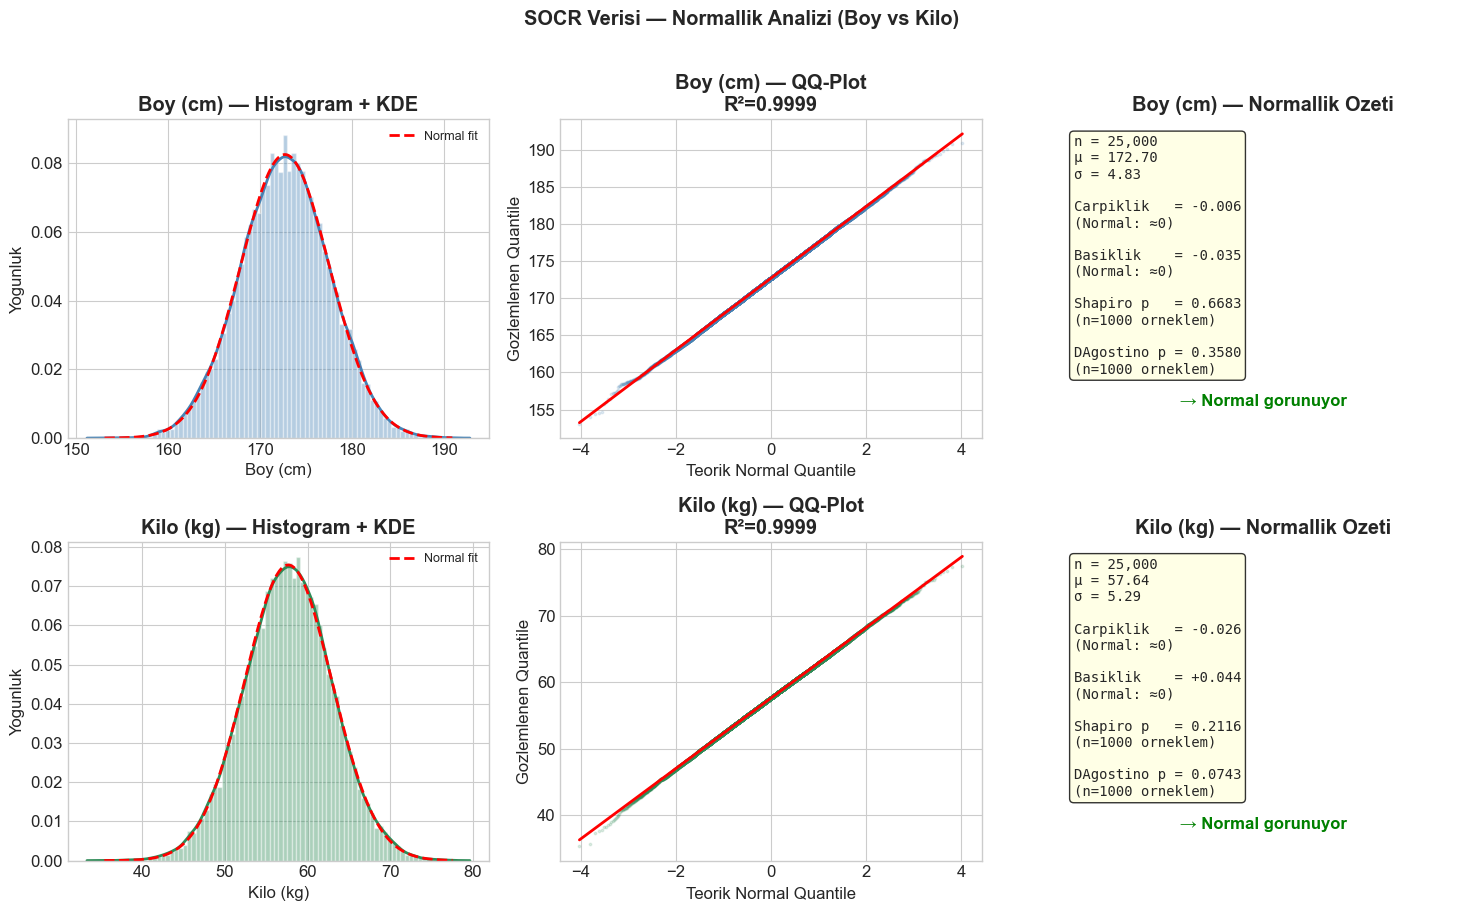

QQ-Plot yorum rehberi:
  R^2 > 0.99 → Normal fit cok iyi
  Carpiklik ∈ [-0.5, 0.5] → kabul edilebilir simetri
  Basiklik ∈ [-1, 1]  → Normal benzeri kuyruk


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

kolonlar = [
    ('height_cm', 'Boy (cm)', 'steelblue'),
    ('weight_kg', 'Kilo (kg)', 'seagreen'),
]

for satir, (kolon, etiket, renk) in enumerate(kolonlar):
    veri = df[kolon]
    # Buyuk veride normallik testi: orneklem al
    # Shapiro-Wilk n>5000 icin tasarlanmamis — 1000 orneklem al
    orneklem = veri.sample(1000, random_state=42)

    # ─── Sol: Histogram + KDE ──────────────────────────────────────────────
    ax = axes[satir][0]
    ax.hist(veri, bins=80, density=True, color=renk, alpha=0.4,
            edgecolor='white')
    sns.kdeplot(veri, ax=ax, color=renk, linewidth=2)
    mu_f, sig_f = stats.norm.fit(veri)
    x_r = np.linspace(veri.min(), veri.max(), 300)
    ax.plot(x_r, stats.norm.pdf(x_r, mu_f, sig_f), 'r--',
            linewidth=2, label='Normal fit')
    ax.set_title(f'{etiket} — Histogram + KDE', fontweight='bold')
    ax.set_xlabel(etiket)
    ax.set_ylabel('Yogunluk')
    ax.legend(fontsize=9)

    # ─── Orta: QQ-Plot ─────────────────────────────────────────────────────
    ax = axes[satir][1]
    # probplot: (teorik quantile, gozlemlenen deger) ciftleri
    (teorik_q, gozlem_q), (slope, intercept, r) = stats.probplot(veri, dist='norm')
    ax.scatter(teorik_q, gozlem_q, color=renk, alpha=0.15, s=3)
    # Referans dogrusu: y = slope*x + intercept
    x_line = np.array([teorik_q.min(), teorik_q.max()])
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)
    ax.set_title(f'{etiket} — QQ-Plot\nR²={r**2:.4f}', fontweight='bold')
    ax.set_xlabel('Teorik Normal Quantile')
    ax.set_ylabel('Gozlemlenen Quantile')

    # ─── Sag: Carpiklik / Basiklik / Test ─────────────────────────────────
    ax = axes[satir][2]
    carpiklik = stats.skew(veri)
    basiklik  = stats.kurtosis(veri)   # excess kurtosis (Normal icin 0)
    # D'Agostino-Pearson: n<5000 icin normaltest, burada orneklem
    _, p_dag  = stats.normaltest(orneklem)
    _, p_shap = stats.shapiro(orneklem)

    # Ozet metni
    ozet = (
        f'n = {len(veri):,}\n'
        f'μ = {mu_f:.2f}\n'
        f'σ = {sig_f:.2f}\n'
        f'\n'
        f'Carpiklik   = {carpiklik:+.3f}\n'
        f'(Normal: ≈0)\n'
        f'\n'
        f'Basiklik    = {basiklik:+.3f}\n'
        f'(Normal: ≈0)\n'
        f'\n'
        f'Shapiro p   = {p_shap:.4f}\n'
        f'(n=1000 orneklem)\n'
        f'\n'
        f'DAgostino p = {p_dag:.4f}\n'
        f'(n=1000 orneklem)'
    )
    yorum = 'Normal gorunuyor' if abs(carpiklik) < 0.3 and abs(basiklik) < 0.5 else 'Normal degil'
    ax.text(0.05, 0.95, ozet, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
            fontfamily='monospace')
    ax.text(0.5, 0.1, f'→ {yorum}', transform=ax.transAxes,
            fontsize=12, ha='center', fontweight='bold',
            color='green' if 'Normal gorunuyor' in yorum else 'red')
    ax.axis('off')
    ax.set_title(f'{etiket} — Normallik Ozeti', fontweight='bold')

plt.suptitle('SOCR Verisi — Normallik Analizi (Boy vs Kilo)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('QQ-Plot yorum rehberi:')
print('  R^2 > 0.99 → Normal fit cok iyi')
print('  Carpiklik ∈ [-0.5, 0.5] → kabul edilebilir simetri')
print('  Basiklik ∈ [-1, 1]  → Normal benzeri kuyruk')


---
### 🎲 Python 4 — Uniform Dağılım: PDF, CDF ve CLT Bağlantısı

**Ne yapıyoruz?**
1. Uniform PDF ve CDF görselleştirmesi
2. CLT bağlantısı: $n$ Uniform'un toplamı Normal'e nasıl yaklaşıyor?

**Mantık:**
- `stats.uniform(loc=a, scale=b-a)` → Uniform $(a, b)$ nesnesi  
  Dikkat: scipy'da `scale = b - a` (aralık genişliği), `loc = a` (başlangıç)
- CLT gösterimi için `rng.uniform(0, 1, size=(n_sim, n))` → n_sim × n matris  
  Her satır: n tane Uniform örneği  
  `.sum(axis=1)` → her satırın toplamı → Normal'e yaklaşan dağılım

P(4 < X < 7) = (x2-x1)/(b-a) = (7-4)/(8-2) = 0.5000


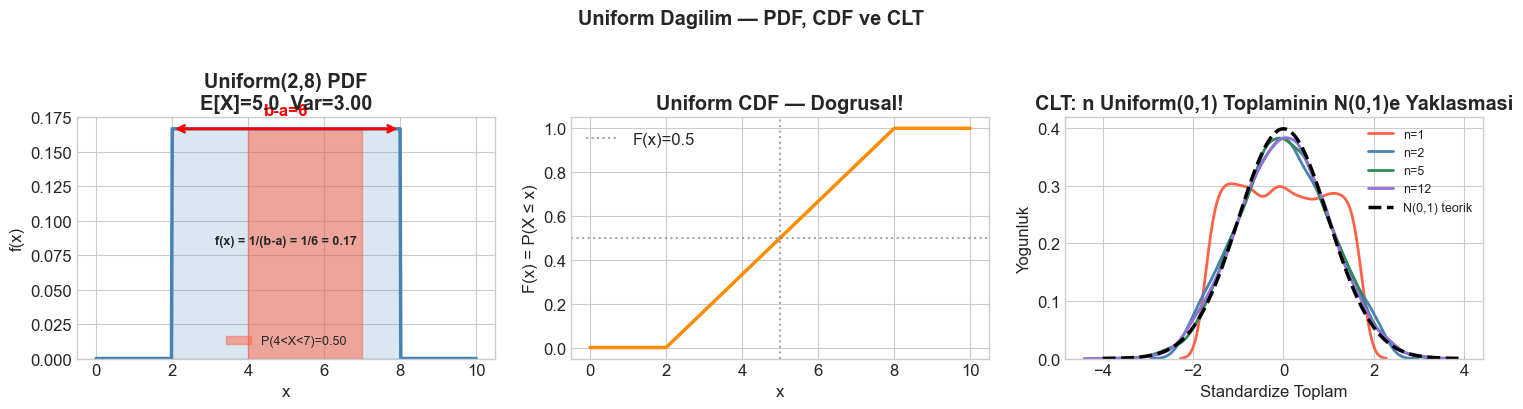

In [5]:
rng = np.random.default_rng(42)

# ─── Uniform PDF ve CDF ───────────────────────────────────────────────────────
a, b = 2, 8
dist_u = stats.uniform(loc=a, scale=b-a)   # Uniform(a, b)
x_u    = np.linspace(0, 10, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PDF
ax = axes[0]
ax.plot(x_u, dist_u.pdf(x_u), 'steelblue', linewidth=2.5)
ax.fill_between(x_u, dist_u.pdf(x_u), alpha=0.2, color='steelblue')
ax.set_ylim(bottom=0)
ax.annotate('',
            xy=(b, dist_u.pdf(5)), xytext=(a, dist_u.pdf(5)),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text((a+b)/2, dist_u.pdf(5)+0.01, f'b-a={b-a}', ha='center',
        color='red', fontweight='bold')
ax.text((a+b)/2, dist_u.pdf(5)/2,
        f'f(x) = 1/(b-a) = 1/{b-a} = {1/(b-a):.2f}',
        ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Uniform({a},{b}) PDF\nE[X]={(a+b)/2:.1f}  Var={(b-a)**2/12:.2f}', fontweight='bold')

# CDF — dogrusal
ax = axes[1]
ax.plot(x_u, dist_u.cdf(x_u), 'darkorange', linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='F(x)=0.5')
ax.axvline((a+b)/2, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('x')
ax.set_ylabel('F(x) = P(X ≤ x)')
ax.set_title('Uniform CDF — Dogrusal!', fontweight='bold')
ax.legend()

# Olaslik ornegi
x1, x2 = 4, 7
p_aralik = dist_u.cdf(x2) - dist_u.cdf(x1)
x_fill   = np.linspace(x1, x2, 100)
axes[0].fill_between(x_fill, dist_u.pdf(x_fill), alpha=0.5, color='tomato',
                     label=f'P({x1}<X<{x2})={(x2-x1)/(b-a):.2f}')
axes[0].legend(fontsize=9)

print(f'P({x1} < X < {x2}) = (x2-x1)/(b-a) = ({x2}-{x1})/({b}-{a}) = {p_aralik:.4f}')

# ─── CLT: Uniform toplaminin Normal'e yaklasmasi ─────────────────────────────
ax = axes[2]
n_sim  = 5000
renkler = ['tomato', 'steelblue', 'seagreen', 'mediumpurple']

for n, renk in zip([1, 2, 5, 12], renkler):
    # n tane Uniform(0,1) uret ve topla
    toplamlar = rng.uniform(0, 1, size=(n_sim, n)).sum(axis=1)

    # Standardize: CLT teorisi
    # Uniform(0,1) icin: E[X]=0.5, Var(X)=1/12
    mu_t  = n * 0.5
    std_t = np.sqrt(n / 12)
    z     = (toplamlar - mu_t) / std_t

    sns.kdeplot(z, ax=ax, label=f'n={n}', color=renk, linewidth=2)

# Standart Normal referans
x_ref = np.linspace(-4, 4, 300)
ax.plot(x_ref, stats.norm.pdf(x_ref), 'k--', linewidth=2.5, label='N(0,1) teorik')

ax.set_xlabel('Standardize Toplam')
ax.set_ylabel('Yogunluk')
ax.set_title('CLT: n Uniform(0,1) Toplaminin N(0,1)e Yaklasmasi', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Uniform Dagilim — PDF, CDF ve CLT', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
### 📐 Python 5 — Z-Score: Standardizasyon ve Karşılaştırma

**Ne yapıyoruz?**  
Z-score dönüşümünü SOCR verisiyle uygulayarak pratik anlam kazandırıyoruz.

**Mantık:**
$$Z = \frac{X - \mu}{\sigma}$$

Z-score şu sorulara cevap verir:
- "177 cm boy, ortalamanın kaç standart sapma üzerinde?"
- "Bu kişi nüfusun yüzde kaçından daha uzun?"
- "Boy ve kilo farklı birimlerdeyken hangi özellikte daha 'aykırı'?"

**Pratik kullanımlar:**
- ML'de feature normalization (StandardScaler)
- Aykırı değer (outlier) tespiti: `|Z| > 3` → aykırı değer
- Farklı ölçek ve birimlerdeki değişkenleri karşılaştırma

=== Z-score Ozeti ===
            z_boy      z_kilo
count  25000.0000  25000.0000
mean      -0.0000     -0.0000
std        1.0000      1.0000
min       -4.0569     -4.2077
25%       -0.6777     -0.6664
50%        0.0014      0.0067
75%        0.6730      0.6701
max        3.7650      3.7600

=== Spesifik Z-Score ve Yuzdelik Hesaplari ===
  Boy (cm)    Z-score     Yuzdelik Yorum
       160     -2.630         0.4% Cok kisa
       170     -0.560        28.8% Ortalama
       177     +0.890        81.3% Ortalama
       185     +2.546        99.5% Cok uzun
       195     +4.616       100.0% Cok uzun


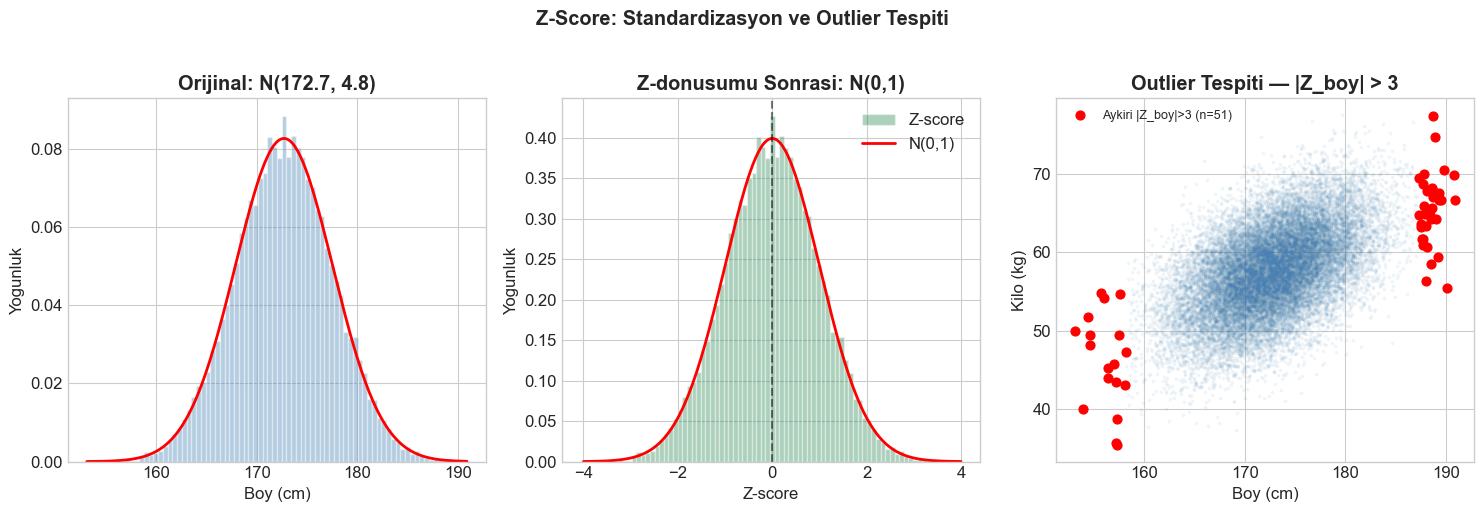


Aykiri deger sayisi (|Z|>3) : 51 / 25,000 = %0.20
Teorik beklenti (Normal)    : %0.27 = 67 kisi


In [6]:
# ─── Z-score hesabi ───────────────────────────────────────────────────────────
df['z_boy']  = (df['height_cm'] - mu_boy)  / sigma_boy
df['z_kilo'] = (df['weight_kg'] - mu_kilo) / sigma_kilo

print('=== Z-score Ozeti ===')
print(df[['z_boy','z_kilo']].describe().round(4))

# ─── Ornekler: spesifik Z-score yorumu ──────────────────────────────────────
boy_ornekler = [160, 170, 177, 185, 195]
print(f'\n=== Spesifik Z-Score ve Yuzdelik Hesaplari ===')
print(f'{"Boy (cm)":>10} {"Z-score":>10} {"Yuzdelik":>12} {"Yorum"}')
for boy in boy_ornekler:
    z     = (boy - mu_boy) / sigma_boy
    yuzde = stats.norm.cdf(z) * 100
    yorum = (
        'Cok kisa' if z < -2 else
        'Kisa'     if z < -1 else
        'Ortalama' if z <  1 else
        'Uzun'     if z <  2 else
        'Cok uzun'
    )
    print(f'{boy:>10.0f} {z:>+10.3f} {yuzde:>11.1f}% {yorum}')

# ─── Grafik: orijinal vs Z-score ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sol: Orijinal boy dagilimy
ax = axes[0]
ax.hist(df['height_cm'], bins=80, density=True, color='steelblue', alpha=0.4,
        edgecolor='white')
x_r = np.linspace(df['height_cm'].min(), df['height_cm'].max(), 300)
ax.plot(x_r, stats.norm.pdf(x_r, mu_boy, sigma_boy), 'r-', linewidth=2)
ax.set_xlabel('Boy (cm)')
ax.set_ylabel('Yogunluk')
ax.set_title(f'Orijinal: N({mu_boy:.1f}, {sigma_boy:.1f})', fontweight='bold')

# Orta: Z-score dagilimy (standart normal olmali)
ax = axes[1]
ax.hist(df['z_boy'], bins=80, density=True, color='seagreen', alpha=0.4,
        edgecolor='white', label='Z-score')
x_z = np.linspace(-4, 4, 300)
ax.plot(x_z, stats.norm.pdf(x_z, 0, 1), 'r-', linewidth=2, label='N(0,1)')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Z-score')
ax.set_ylabel('Yogunluk')
ax.set_title('Z-donusumu Sonrasi: N(0,1)', fontweight='bold')
ax.legend()

# Sag: Outlier tespiti (|Z| > 3)
ax = axes[2]
df['outlier_boy'] = df['z_boy'].abs() > 3
normal = df[~df['outlier_boy']]
aykiri = df[df['outlier_boy']]

ax.scatter(df['height_cm'], df['weight_kg'], alpha=0.05, s=3, color='steelblue')
ax.scatter(aykiri['height_cm'], aykiri['weight_kg'],
           color='red', s=40, zorder=5, label=f'Aykiri |Z_boy|>3 (n={len(aykiri)})')
ax.set_xlabel('Boy (cm)')
ax.set_ylabel('Kilo (kg)')
ax.set_title('Outlier Tespiti — |Z_boy| > 3', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Z-Score: Standardizasyon ve Outlier Tespiti', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_aykiri = len(aykiri)
print(f'\nAykiri deger sayisi (|Z|>3) : {n_aykiri} / {len(df):,} = %{n_aykiri/len(df)*100:.2f}')
print(f'Teorik beklenti (Normal)    : %{(1-0.9973)*100:.2f} = {int(len(df)*(1-0.9973))} kisi')


---
# 📊 R Uygulaması

R'da Normal ve Uniform için 4'lü fonksiyon ailesi:

| Prefix | Normal | Uniform | Python karşılığı |
|---|---|---|---|
| `d` (PDF) | `dnorm(x, mean, sd)` | `dunif(x, min, max)` | `.pdf(x)` |
| `p` (CDF) | `pnorm(q, mean, sd)` | `punif(q, min, max)` | `.cdf(q)` |
| `q` (Quantile) | `qnorm(p, mean, sd)` | `qunif(p, min, max)` | `.ppf(p)` |
| `r` (Örnekleme) | `rnorm(n, mean, sd)` | `runif(n, min, max)` | `.rvs(size=n)` |

**Yeni R kavramları:** `qqnorm()`, `qqline()`, `shapiro.test()`

In [22]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


---
### 📈 R 1 — Normal: PDF/CDF, QQ-Plot ve Normallik Testi

`qqnorm(x)` → Standart Normal QQ-Plot çizer (Python'daki `scipy.stats.probplot` karşılığı)  
`qqline(x)` → QQ-Plot'a referans doğrusu ekler  
`shapiro.test(x)` → Shapiro-Wilk testi (Python'daki `stats.shapiro` karşılığı)

Boy : N(mu= 172.7 , sd= 4.83 )
Kilo: N(mu= 57.64 , sd= 5.29 )

=== Normal Olasilik Sorulari ===
P(X < 170 cm)        = 0.2879 
P(X > 185 cm)        = 0.0054 
P(163 < X < 177 cm)  = 0.7909 
%90 boy yuzdeligi    = 178.9 cm


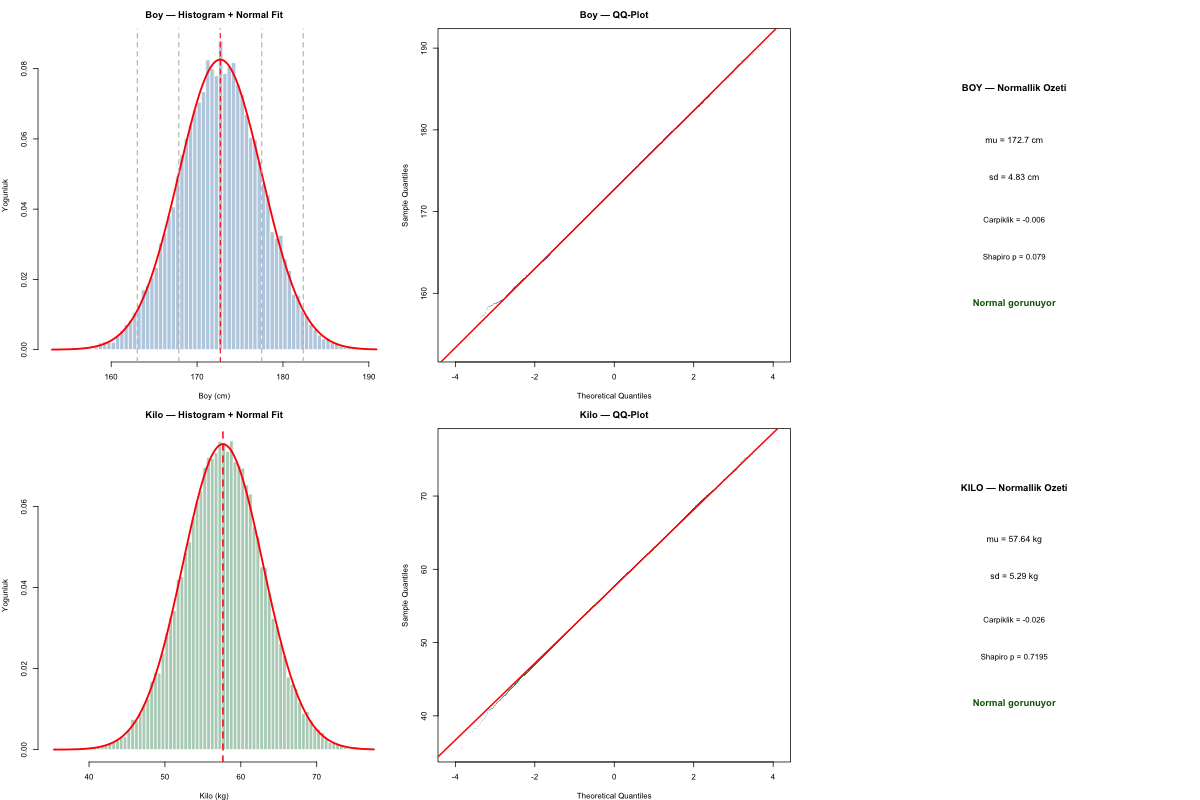

In [17]:
%%R -i df -w 1200 -h 800
# df: Python'daki DataFrame (height_cm, weight_kg, z_boy sutunlari iceriyor)

boy  <- df$height_cm
kilo <- df$weight_kg

# MLE parametreler
mu_boy   <- mean(boy)
sd_boy   <- sd(boy)
mu_kilo  <- mean(kilo)
sd_kilo  <- sd(kilo)

cat('Boy : N(mu=', round(mu_boy,2), ', sd=', round(sd_boy,2), ')\n')
cat('Kilo: N(mu=', round(mu_kilo,2), ', sd=', round(sd_kilo,2), ')\n')

par(mfrow = c(2, 3), mar = c(4, 4, 3, 1))

# ─── Ust sira: Boy ────────────────────────────────────────────────────────────
# Histogram + Normal fit
hist(boy, breaks=80, freq=FALSE,
     col=adjustcolor('steelblue', 0.4), border='white',
     main='Boy — Histogram + Normal Fit',
     xlab='Boy (cm)', ylab='Yogunluk')
x_r <- seq(min(boy), max(boy), length.out=300)
lines(x_r, dnorm(x_r, mu_boy, sd_boy), col='red', lwd=2.5)
# mu +/- sigma cizgileri
abline(v=mu_boy + c(-2,-1,0,1,2)*sd_boy,
       col=c('gray','gray','red','gray','gray'),
       lty=c(2,2,2,2,2), lwd=1.5)

# QQ-Plot
# qqnorm: Standart Normal QQ-Plot (Python'daki probplot ile ayni anlam)
# qqline: referans dogrusu (y = slope*x + intercept)
qqnorm(boy, pch='.', col=adjustcolor('steelblue', 0.3),
       main='Boy — QQ-Plot')
qqline(boy, col='red', lwd=2)   # referans dogrusu: uzerinde = Normal

# Normallik ozet
orneklem_boy <- sample(boy, 1000)   # shapiro.test n<5000 gerektirir
shap_boy     <- shapiro.test(orneklem_boy)
plot(0, type='n', xlim=c(0,1), ylim=c(0,1), axes=FALSE, xlab='', ylab='')
text(0.5, 0.85, 'BOY — Normallik Ozeti', cex=1.2, font=2)
text(0.5, 0.68, paste0('mu = ', round(mu_boy, 2), ' cm'), cex=1.1)
text(0.5, 0.56, paste0('sd = ', round(sd_boy, 2), ' cm'), cex=1.1)
text(0.5, 0.42, paste0('Carpiklik = ', round(moments::skewness(boy), 3)), cex=1.0)
text(0.5, 0.30, paste0('Shapiro p = ', round(shap_boy$p.value, 4)), cex=1.0)
text(0.5, 0.15,
     ifelse(shap_boy$p.value > 0.05, 'Normal gorunuyor', 'Normal degil'),
     cex=1.2, font=2,
     col=ifelse(shap_boy$p.value > 0.05, 'darkgreen', 'red'))

# ─── Alt sira: Kilo ───────────────────────────────────────────────────────────
hist(kilo, breaks=80, freq=FALSE,
     col=adjustcolor('seagreen', 0.4), border='white',
     main='Kilo — Histogram + Normal Fit',
     xlab='Kilo (kg)', ylab='Yogunluk')
x_k <- seq(min(kilo), max(kilo), length.out=300)
lines(x_k, dnorm(x_k, mu_kilo, sd_kilo), col='red', lwd=2.5)
abline(v=mu_kilo, col='red', lty=2, lwd=2)

qqnorm(kilo, pch='.', col=adjustcolor('seagreen', 0.3),
       main='Kilo — QQ-Plot')
qqline(kilo, col='red', lwd=2)

orneklem_kilo <- sample(kilo, 1000)
shap_kilo     <- shapiro.test(orneklem_kilo)
plot(0, type='n', xlim=c(0,1), ylim=c(0,1), axes=FALSE, xlab='', ylab='')
text(0.5, 0.85, 'KILO — Normallik Ozeti', cex=1.2, font=2)
text(0.5, 0.68, paste0('mu = ', round(mu_kilo, 2), ' kg'), cex=1.1)
text(0.5, 0.56, paste0('sd = ', round(sd_kilo, 2), ' kg'), cex=1.1)
text(0.5, 0.42, paste0('Carpiklik = ', round(moments::skewness(kilo), 3)), cex=1.0)
text(0.5, 0.30, paste0('Shapiro p = ', round(shap_kilo$p.value, 4)), cex=1.0)
text(0.5, 0.15,
     ifelse(shap_kilo$p.value > 0.05, 'Normal gorunuyor', 'Normal degil'),
     cex=1.2, font=2,
     col=ifelse(shap_kilo$p.value > 0.05, 'darkgreen', 'red'))

par(mfrow = c(1, 1))

# Sayisal kontroller
cat('\n=== Normal Olasilik Sorulari ===\n')
cat('P(X < 170 cm)        =', round(pnorm(170, mu_boy, sd_boy), 4), '\n')
cat('P(X > 185 cm)        =', round(1 - pnorm(185, mu_boy, sd_boy), 4), '\n')
cat('P(163 < X < 177 cm)  =', round(pnorm(177,mu_boy,sd_boy) - pnorm(163,mu_boy,sd_boy), 4), '\n')
cat('%90 boy yuzdeligi    =', round(qnorm(0.90, mu_boy, sd_boy), 1), 'cm\n')


---
### 🎲 R 2 — Uniform PDF/CDF ve CLT Gösterimi

`dunif(x, min, max)` → Uniform PDF  
`punif(q, min, max)` → Uniform CDF  
`runif(n, min, max)` → Uniform örnekleme  

**Yeni R kavramı:** `replicate(n, expr)` → bir ifadeyi n kez çalıştır  
CLT için: her seferinde n tane Uniform üret ve topla → n_sim adet toplam

=== Uniform(2,8) Olasilik Sorulari ===
P(X < 5)     = 0.5 
P(4 < X < 7) = 0.5 
%75 yuzdelik = 6.5 


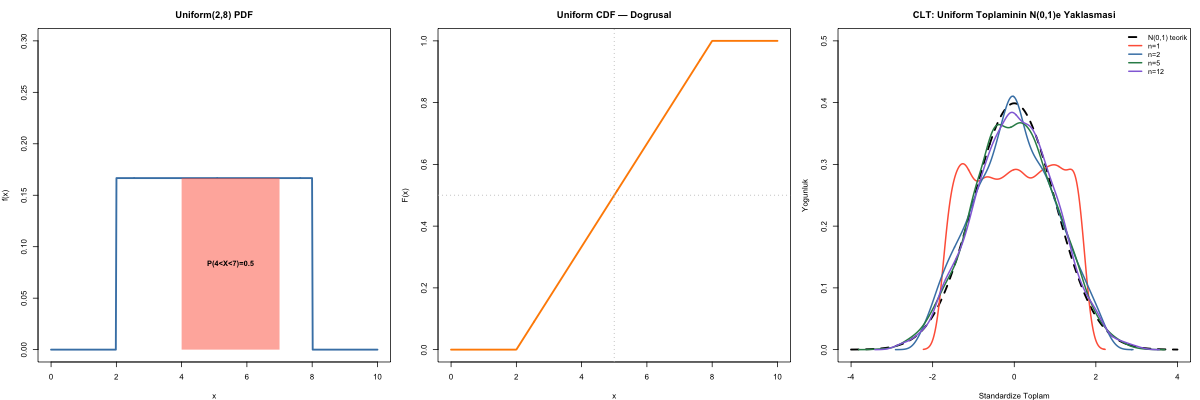

In [19]:
%%R -w 1200 -h 400
set.seed(42)

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# ─── Sol: Uniform PDF ve CDF ─────────────────────────────────────────────────
a <- 2; b <- 8
x_u <- seq(0, 10, length.out = 500)

plot(x_u, dunif(x_u, a, b),
     type = 'l', col = 'steelblue', lwd = 2.5,
     ylim = c(0, 0.3),
     main = paste0('Uniform(', a, ',', b, ') PDF'),
     xlab = 'x', ylab = 'f(x)')
# Alan golgele: P(4 < X < 7)
x_fill <- seq(4, 7, length.out=100)
polygon(c(4, x_fill, 7), c(0, dunif(x_fill,a,b), 0),
        col=adjustcolor('tomato', 0.5), border=NA)
text(5.5, dunif(5.5,a,b)/2, 'P(4<X<7)=0.5', cex=0.95, font=2)

plot(x_u, punif(x_u, a, b),
     type = 'l', col = 'darkorange', lwd = 2.5,
     main = 'Uniform CDF — Dogrusal',
     xlab = 'x', ylab = 'F(x)')
abline(h = 0.5, col = 'gray', lty = 3)
abline(v = (a+b)/2, col = 'gray', lty = 3)

# ─── Sag: CLT — n Uniform toplaminin N(0,1)e yaklasmasi ──────────────────────
n_sim   <- 5000
n_vals  <- c(1, 2, 5, 12)
renkler <- c('tomato', 'steelblue', 'seagreen', 'mediumpurple')

# Standart Normal referans ciz
x_ref <- seq(-4, 4, length.out=300)
plot(x_ref, dnorm(x_ref), type='l', lwd=2.5, lty=2,
     col='black', main='CLT: Uniform Toplaminin N(0,1)e Yaklasmasi',
     xlab='Standardize Toplam', ylab='Yogunluk', ylim=c(0, 0.5))

for (i in seq_along(n_vals)) {
  n <- n_vals[i]
  # n tane Uniform(0,1) ornekle ve topla — n_sim kez
  # replicate(n_sim, sum(runif(n))) → n_sim adet toplam
  toplamlar <- replicate(n_sim, sum(runif(n)))

  # Standardize: Z = (toplam - n*0.5) / sqrt(n/12)
  mu_t  <- n * 0.5
  std_t <- sqrt(n / 12)
  z     <- (toplamlar - mu_t) / std_t

  lines(density(z), col=renkler[i], lwd=2, lty=1)
}

legend('topright',
       legend = c('N(0,1) teorik', paste0('n=', n_vals)),
       col    = c('black', renkler),
       lwd    = c(2.5, rep(2,4)),
       lty    = c(2, rep(1,4)),
       bty='n', cex=0.9)

par(mfrow = c(1, 1))

# Sayisal kontroller
cat('=== Uniform(2,8) Olasilik Sorulari ===\n')
cat('P(X < 5)     =', round(punif(5, 2, 8), 4), '\n')
cat('P(4 < X < 7) =', round(punif(7,2,8) - punif(4,2,8), 4), '\n')
cat('%75 yuzdelik =', round(qunif(0.75, 2, 8), 4), '\n')


---
# 🗄️ SQL Uygulaması (DuckDB)

SQL'de Normal ve Uniform analizi:
1. **Z-score** → `(value - AVG()) / STDDEV()` ile her satır için
2. **Normallik kontrol** → çarpıklık ve basıklık fonksiyonları
3. **Outlier tespiti** → `|Z| > 3` filtresi
4. **Histogram bucket** → `WIDTH_BUCKET()` ile

**Yeni SQL kavramı:** `WIDTH_BUCKET(val, min, max, n_bins)`  
Değerleri eşit genişlikli gruplara böler — histogram çizmek için SQL'in temel aracı.

In [24]:
import duckdb

con = duckdb.connect()
con.register('socr', df)
print('DuckDB hazir ✓')
print(f'socr tablosu: {len(df):,} satir')


DuckDB hazir ✓
socr tablosu: 25,000 satir


---
### 📐 SQL 1 — Z-Score ve Normallik İstatistikleri

DuckDB'de window function ile Z-score hesabı:
```sql
(value - AVG(value) OVER ()) / STDDEV_POP(value) OVER ()   AS z_score
```

Basıklık için DuckDB'de `KURTOSIS()`, çarpıklık için `SKEWNESS()` hazır fonksiyon olarak gelir.

In [25]:
# Ozet istatistikler + carpiklik + basiklik
ozet = con.execute("""
    SELECT
        'boy_cm'                            AS degisken,
        COUNT(*)                            AS n,
        ROUND(AVG(height_cm), 2)            AS ortalama,
        ROUND(STDDEV_POP(height_cm), 2)     AS std_sapma,
        ROUND(MIN(height_cm), 2)            AS minimum,
        ROUND(MAX(height_cm), 2)            AS maksimum,
        ROUND(SKEWNESS(height_cm), 4)       AS carpiklik,
        ROUND(KURTOSIS(height_cm), 4)       AS basiklik_excess
    FROM socr
    UNION ALL
    SELECT
        'kilo_kg',
        COUNT(*),
        ROUND(AVG(weight_kg), 2),
        ROUND(STDDEV_POP(weight_kg), 2),
        ROUND(MIN(weight_kg), 2),
        ROUND(MAX(weight_kg), 2),
        ROUND(SKEWNESS(weight_kg), 4),
        ROUND(KURTOSIS(weight_kg), 4)
    FROM socr
""").df()

print('=== Normallik Istatistikleri ===')
print(ozet.to_string(index=False))
print('\nYorum: Carpiklik ~0, Basiklik ~0 ise Normal dagilim')

# Z-score hesabi + outlier bayragi
zscore_sql = con.execute("""
    SELECT
        height_cm,
        weight_kg,
        -- Z-score: (deger - ortalama) / std_sapma
        -- OVER (): tum tablo uzerinden pencere
        ROUND(
            (height_cm - AVG(height_cm) OVER ())
            / STDDEV_POP(height_cm) OVER (),
        3) AS z_boy,
        ROUND(
            (weight_kg - AVG(weight_kg) OVER ())
            / STDDEV_POP(weight_kg) OVER (),
        3) AS z_kilo,
        -- Outlier bayragi
        ABS((height_cm - AVG(height_cm) OVER ())
            / STDDEV_POP(height_cm) OVER ()) > 3   AS outlier_boy,
        ABS((weight_kg - AVG(weight_kg) OVER ())
            / STDDEV_POP(weight_kg) OVER ()) > 3   AS outlier_kilo
    FROM socr
    ORDER BY ABS((height_cm - AVG(height_cm) OVER ())
                 / STDDEV_POP(height_cm) OVER ()) DESC
    LIMIT 10
""").df()

print('\n=== En Aykiri 10 Gozlem (|Z_boy| buyukten kucuge) ===')
print(zscore_sql.to_string(index=False))


=== Normallik Istatistikleri ===
degisken     n  ortalama  std_sapma  minimum  maksimum  carpiklik  basiklik_excess
  boy_cm 25000    172.70       4.83   153.11    190.89    -0.0057          -0.0352
 kilo_kg 25000     57.64       5.29    35.39     77.53    -0.0260           0.0447

Yorum: Carpiklik ~0, Basiklik ~0 ise Normal dagilim

=== En Aykiri 10 Gozlem (|Z_boy| buyukten kucuge) ===
 height_cm  weight_kg  z_boy  z_kilo  outlier_boy  outlier_kilo
153.107034  49.946739 -4.057  -1.455         True         False
153.956131  39.937170 -3.881  -3.347         True          True
154.447748  51.670706 -3.779  -1.129         True         False
190.888112  66.664462  3.765   1.706         True         False
154.593036  48.168703 -3.749  -1.791         True         False
154.609216  49.379522 -3.746  -1.562         True         False
190.792583  69.833301  3.745   2.305         True         False
190.116206  55.413702  3.605  -0.421         True         False
189.840794  70.554512  3.548   2.4

---
### 📊 SQL 2 — WIDTH_BUCKET ile Histogram ve 68-95-99.7 Kontrolü

`WIDTH_BUCKET(val, min, max, n_bins)` → değeri n eşit aralığa yerleştirir  
Döndürdüğü değer bucket numarasıdır (1-indexed).

68-95-99.7 kuralını SQL'de `CASE WHEN` ile kontrol edebiliriz:
```sql
CASE WHEN ABS(z_score) <= 1 THEN 'mu±1sigma' ...
```

In [27]:
# Histogram: WIDTH_BUCKET (DuckDB'de yok) ile boy verisi
hist_sql = con.execute("""
    WITH bucket_calc AS (
        SELECT
            height_cm,
            -- Alt ve üst sınırlara göre (215-140=75) bucket hesaplama
            FLOOR((height_cm - 140.0) / 75.0 * 30) + 1 AS raw_bucket,
            -- Taşmaları engelleme (0: underflow, 31: overflow)
            CASE 
                WHEN height_cm < 140 THEN 0
                WHEN height_cm >= 215 THEN 31
                ELSE raw_bucket::INTEGER
            END AS bucket_no
        FROM socr
    )
    SELECT
        bucket_no,
        -- Her bucket'in alt sınırı
        ROUND(140.0 + (bucket_no - 1) * (75.0 / 30.0), 1) AS aralik_alt,
        COUNT(*) AS frekans,
        ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (), 4) AS oran
    FROM bucket_calc
    GROUP BY bucket_no
    ORDER BY bucket_no
""").df()

print('=== Boy Histogram (30 bucket) ===')
print(hist_sql.to_string(index=False))


# 68-95-99.7 kurali SQL kontrolu
kural = con.execute("""
    WITH z AS (
        SELECT
            (height_cm - AVG(height_cm) OVER ())
            / STDDEV_POP(height_cm) OVER ()    AS z_boy
        FROM socr
    )
    SELECT
        -- Her araliktaki gozlem sayisi
        ROUND(SUM(CASE WHEN ABS(z_boy) <= 1 THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 2)            AS pct_1sigma,
        ROUND(SUM(CASE WHEN ABS(z_boy) <= 2 THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 2)            AS pct_2sigma,
        ROUND(SUM(CASE WHEN ABS(z_boy) <= 3 THEN 1 ELSE 0 END)
              * 100.0 / COUNT(*), 2)            AS pct_3sigma,
        SUM(CASE WHEN ABS(z_boy) > 3 THEN 1 ELSE 0 END) AS n_outlier
    FROM z
""").df()

print('\n=== 68-95-99.7 Kurali SQL Dogrulamasi ===')
print(f'μ±1σ icindeki gozlemler: %{kural["pct_1sigma"].values[0]}  (teorik: %68.27)')
print(f'μ±2σ icindeki gozlemler: %{kural["pct_2sigma"].values[0]}  (teorik: %95.45)')
print(f'μ±3σ icindeki gozlemler: %{kural["pct_3sigma"].values[0]}  (teorik: %99.73)')
print(f'|Z|>3 outlier sayisi   : {kural["n_outlier"].values[0]}')


=== Boy Histogram (30 bucket) ===
 bucket_no  aralik_alt  frekans   oran
         6       152.5        5 0.0002
         7       155.0        9 0.0004
         8       157.5       90 0.0036
         9       160.0      332 0.0133
        10       162.5      991 0.0396
        11       165.0     2068 0.0827
        12       167.5     3718 0.1487
        13       170.0     4804 0.1922
        14       172.5     5058 0.2023
        15       175.0     3914 0.1566
        16       177.5     2365 0.0946
        17       180.0     1133 0.0453
        18       182.5      374 0.0150
        19       185.0      109 0.0044
        20       187.5       27 0.0011
        21       190.0        3 0.0001

=== 68-95-99.7 Kurali SQL Dogrulamasi ===
μ±1σ icindeki gozlemler: %68.36  (teorik: %68.27)
μ±2σ icindeki gozlemler: %95.46  (teorik: %95.45)
μ±3σ icindeki gozlemler: %99.8  (teorik: %99.73)
|Z|>3 outlier sayisi   : 51.0


---
## ✏️ Egzersizler


---
### E1 — Normal Olasılık Hesabı (Temel)
SOCR verisi üzerinde aşağıdaki soruları hem formülle hem Python/R/SQL ile cevapla:

a) Türk erkek boyları $N(\mu=176, \sigma=7)$ dağıldığını varsayalım.  
   - Bir kişi rastgele seçildiğinde 185 cm'den uzun olma ihtimali nedir?  
   - NBA minimum yükseklik 190 cm. Bu nüfustan NBA'ye girebilecek oran nedir?  
   - Boylar hangi aralıkta ise kişi nüfusun %80'inden uzundur? (`ppf` kullan)

b) SOCR veri setinden:
   - 160 cm altındaki kaç kişi var? SQL ile say, Python ile teorik tahminle karşılaştır.  
   - En uzun %5'lik kesim hangi boy sınırından başlıyor?

In [35]:
print('\n===== Egzersiz 1a: Türk Erkek Boyları =====')
mu = 176
sigma = 7
norm_dist = stats.norm(loc=mu, scale=sigma)

print(f'Normal dagilim: N(μ={mu}, σ={sigma})')

norm_185 = norm_dist.cdf(185)
print(f'P(X > 185) = 1 - P(X ≤ 185) = 1 - {norm_dist.cdf(185):.4f} = {1 - norm_dist.cdf(185):.4f}')

norm_nba = norm_dist.cdf(190)
print(f'P(X > 190) = 1 - P(X ≤ 190) = 1 - {norm_dist.cdf(190):.4f} = {1 - norm_dist.cdf(190):.4f}')

norm_80 = norm_dist.ppf(0.80)
print(f'Yüzde 80\'den uzun boy: {norm_80:.2f} cm')

print('\n===== Egzersiz 1b: SOCR Boyları =====')

# SQL'den gerçek μ ve σ al, empirik oranı da al
norm_sql = con.execute("""
    SELECT
        ROUND(AVG(height_cm), 2)          AS mu,
        ROUND(STDDEV_POP(height_cm), 2)   AS sigma,
        ROUND(
            100.0 * SUM(CASE WHEN height_cm < 160 THEN 1 ELSE 0 END)
            / COUNT(*), 4
        )                                 AS pct_160_empirik,
        ROUND(PERCENTILE_CONT(0.95)
              WITHIN GROUP (ORDER BY height_cm), 2) AS boy_95_empirik
    FROM socr
""").df()

# SQL'den gelen gerçek SOCR parametreleri 
mu_val    = norm_sql['mu'].values[0]      # ← SOCR gerçek ortalaması
sigma_val = norm_sql['sigma'].values[0]   # ← SOCR gerçek std sapması

print(f'SOCR verisi MLE parametreleri: μ={mu_val} cm, σ={sigma_val} cm')
print(f'(NOT: SOCR karma nüfus içeriyor — kadın+erkek karışık)')

# Python: SOCR parametreleriyle teorik Normal
norm_dist = stats.norm(loc=mu_val, scale=sigma_val)

# 160 cm altı
p_160_teorik  = norm_dist.cdf(160)
p_160_empirik = norm_sql['pct_160_empirik'].values[0] / 100

print(f'\nP(X < 160 cm):')
print(f'  Teorik  N({mu_val},{sigma_val}): {p_160_teorik:.4f}  = %{p_160_teorik*100:.2f}')
print(f'  Empirik (SQL sayim)   : {p_160_empirik:.4f}  = %{p_160_empirik*100:.2f}')
print(f'  Fark                  : {abs(p_160_teorik - p_160_empirik):.4f}')

# %95 yüzdelik
p95_teorik  = norm_dist.ppf(0.95)
p95_empirik = norm_sql['boy_95_empirik'].values[0]

print(f"\nEn uzun %5'lik boy sınırı:")
print(f'  Teorik  N({mu_val},{sigma_val}): {p95_teorik:.2f} cm')
print(f'  Empirik (SQL PERCENTILE_CONT): {p95_empirik:.2f} cm')
print(f'  Fark    : {abs(p95_teorik - p95_empirik):.2f} cm')


===== Egzersiz 1a: Türk Erkek Boyları =====
Normal dagilim: N(μ=176, σ=7)
P(X > 185) = 1 - P(X ≤ 185) = 1 - 0.9007 = 0.0993
P(X > 190) = 1 - P(X ≤ 190) = 1 - 0.9772 = 0.0228
Yüzde 80'den uzun boy: 181.89 cm

===== Egzersiz 1b: SOCR Boyları =====
SOCR verisi MLE parametreleri: μ=172.7 cm, σ=4.83 cm
(NOT: SOCR karma nüfus içeriyor — kadın+erkek karışık)

P(X < 160 cm):
  Teorik  N(172.7,4.83): 0.0043  = %0.43
  Empirik (SQL sayim)   : 0.0042  = %0.42
  Fark                  : 0.0001

En uzun %5'lik boy sınırı:
  Teorik  N(172.7,4.83): 180.64 cm
  Empirik (SQL PERCENTILE_CONT): 180.62 cm
  Fark    : 0.02 cm


---
### E2 — QQ-Plot Yorumlama
Aşağıdaki dağılımlardan örneklem üret ve QQ-Plot'larını çiz.  
Her birinin QQ-Plot'unun nasıl göründüğünü yorumla:

```python
ornekler = {
    'Normal(0,1)'      : stats.norm.rvs(size=500, random_state=1),
    'Uniform(0,1)'     : stats.uniform.rvs(size=500, random_state=1),
    'Poisson(lambda=3)': stats.poisson.rvs(mu=3, size=500, random_state=1),
    'Exp(lambda=1)'    : stats.expon.rvs(size=500, random_state=1),
    't(df=3)'          : stats.t.rvs(df=3, size=500, random_state=1),
}
```

- Her birinin QQ-Plot'unu 2×3 grid'de çiz  
- Hangileri düz doğru? Hangileri kıvrık? Neden?  
- Üst kuyruğu şişik görünen (heavy-tailed) dağılımı tanımla


=== Egzersiz 2: QQ-Plot Yorumlama ===


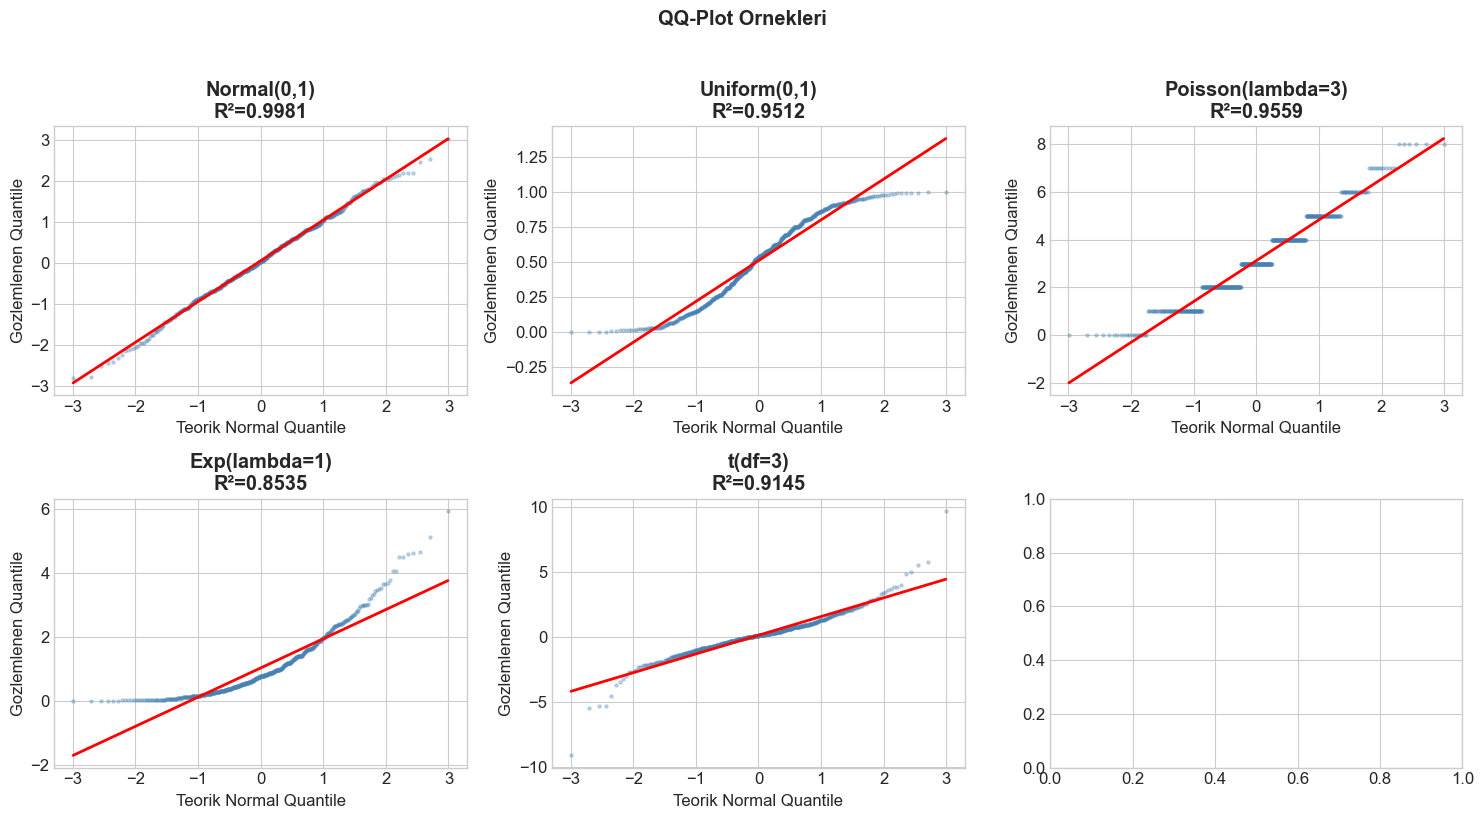


QQ-Plot yorum rehberi:
Normal Dağılım neredeyse yakın R^2 = 99.81
Uniform ise R^2 = 0.9512 S şekli oluşturuyor sol uçta noktalar üstte sağ uçta altta
Poisson ise R^2 = 0.9559 basamak gibi  yani merdiven etkisi yaşaışgitmiş
Exponental ise R^2 0.8535 sağ kuyruk yukarı fırlamış yani sağa çarpık dağılım
t dağılımı R^2 = 0.9145 ters S şekli oluşturuyor yani sol kuyruk yukarı sağ kuyruk aşağı çarpık dağılım


In [38]:
print('\n=== Egzersiz 2: QQ-Plot Yorumlama ===')

ornekler = {
    'Normal(0,1)'      : stats.norm.rvs(size=500, random_state=1),
    'Uniform(0,1)'     : stats.uniform.rvs(size=500, random_state=1),
    'Poisson(lambda=3)': stats.poisson.rvs(mu=3, size=500, random_state=1),
    'Exp(lambda=1)'    : stats.expon.rvs(size=500, random_state=1),
    't(df=3)'          : stats.t.rvs(df=3, size=500, random_state=1),
}

plt.subplots(2, 3, figsize=(15, 8))
for i, (etiket, veri) in enumerate(ornekler.items()):
    satir = i // 3
    sutun = i % 3
    ax = plt.subplot(2, 3, i + 1)

   # QQ-Plot
    (teorik_q, gozlem_q), (slope, intercept, r) = stats.probplot(veri, dist='norm')
    ax.scatter(teorik_q, gozlem_q, color='steelblue', alpha=0.3, s=5)
    x_line = np.array([teorik_q.min(), teorik_q.max()])
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)
    ax.set_title(f'{etiket}\nR²={r**2:.4f}', fontweight='bold')
    ax.set_xlabel('Teorik Normal Quantile')
    ax.set_ylabel('Gozlemlenen Quantile')

plt.suptitle('QQ-Plot Ornekleri', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nQQ-Plot yorum rehberi:')
print('Normal Dağılım neredeyse yakın R^2 = 99.81')
print('Uniform ise R^2 = 0.9512 S şekli oluşturuyor sol uçta noktalar üstte sağ uçta altta')
print('Poisson ise R^2 = 0.9559 basamak gibi  yani merdiven etkisi yaşaışgitmiş')
print('Exponental ise R^2 0.8535 sağ kuyruk yukarı fırlamış yani sağa çarpık dağılım')
print('t dağılımı R^2 = 0.9145 ters S şekli oluşturuyor yani sol kuyruk yukarı sağ kuyruk aşağı çarpık dağılım')

---
### E3 — Z-Score ile Standardizasyon
SOCR verisinde hem boy hem kiloya Z-score uygula.

a) Z-score dönüşümünden sonra `z_boy` ve `z_kilo`'nun beklentisi ve varyansı ne olur?  
   (Teorik cevap ver, sonra Python ile doğrula)

b) Şu soruyu cevapla: "170 cm boyunda ve 70 kg ağırlığında bir kişi,  
   boy bakımından mı daha 'aykırı', kilo bakımından mı?"
   - İki Z-score'u hesapla ve karşılaştır  
   - SQL `CASE WHEN` ile "aykırı/normal" etiketi ekle

c) SOCR verisinde `|Z_boy| > 2.5` olan kişileri filtrele.  
   Bu kişilerin kilo Z-score'larının dağılımı nasıl? (Normal gruba göre fark var mı?)

In [56]:
print('\n=== Egzersiz 3: Z-Score ile Standartlaştırma ===')

mu_boy, sigma_boy = stats.norm.fit(df['height_cm'])
mu_kilo, sigma_kilo = stats.norm.fit(df['weight_kg'])

df['z_boy'] = (df['height_cm'] - mu_boy) / sigma_boy
df['z_kilo'] = (df['weight_kg'] - mu_kilo) / sigma_kilo

z_boy_var = df['z_boy'].var()
z_kilo_var = df['z_kilo'].var()

z_boy_mean = df['z_boy'].mean()
z_kilo_mean = df['z_kilo'].mean()

print('\nZ-Score Standartizasyon Sonuclari:')
print(f'Z-Boy: mean={z_boy_mean:.4f}, var={z_boy_var:.4f}')
print(f'Z-Kilo: mean={z_kilo_mean:.4f}, var={z_kilo_var:.4f}')
print('Z-score ile standartlaştırma sonrası ortalama ~0, varyans ~1 olmalı')

ornek_sql = con.execute("""
    WITH z AS (
            SELECT
                (height_cm - AVG(height_cm) OVER ())
                / STDDEV_POP(height_cm) OVER ()    AS z_boy,
                (weight_kg - AVG(weight_kg) OVER ())
                / STDDEV_POP(weight_kg) OVER ()    AS z_kilo
            FROM socr
        )
        SELECT
            SUM(CASE WHEN ABS(z_boy) > 3 THEN 1 ELSE 0 END) AS n_outlier_boy,
            SUM(CASE WHEN ABS(z_kilo) > 3 THEN 1 ELSE 0 END) AS n_outlier_kilo
        FROM z
""").df()

print('\nSQL ile Z-Score Standartizasyon Sonuclari:')
print(ornek_sql)

ornek_boy = 170
ornek_kilo = 70

z_boy_ornek = (ornek_boy - mu_boy) / sigma_boy
z_kilo_ornek = (ornek_kilo - mu_kilo) / sigma_kilo

print(f'\nOrnek Z-Score Hesaplamalari:')
print(f'Boy: {ornek_boy} cm → Z = {z_boy_ornek:.4f}')
print(f'Kilo: {ornek_kilo} kg → Z = {z_kilo_ornek:.4f}')

if ornek_sql['n_outlier_boy'].values[0] == z_boy_ornek:
    print(f'Boy: {ornek_boy} cm → Aykırı Değer')
elif ornek_sql['n_outlier_boy'].values[0] != z_boy_ornek:
    print(f'Boy: {ornek_boy} cm → Normal Değer')
if ornek_sql['n_outlier_kilo'].values[0] == z_kilo_ornek:
    print(f'Kilo: {ornek_kilo} kg → Aykırı Değer')
elif ornek_sql['n_outlier_kilo'].values[0] != z_kilo_ornek:
    print(f'Kilo: {ornek_kilo} kg → Normal Değer')


=== Egzersiz 3: Z-Score ile Standartlaştırma ===

Z-Score Standartizasyon Sonuclari:
Z-Boy: mean=-0.0000, var=1.0000
Z-Kilo: mean=-0.0000, var=1.0000
Z-score ile standartlaştırma sonrası ortalama ~0, varyans ~1 olmalı

SQL ile Z-Score Standartizasyon Sonuclari:
   n_outlier_boy  n_outlier_kilo
0           51.0            69.0

Ornek Z-Score Hesaplamalari:
Boy: 170 cm → Z = -0.5595
Kilo: 70 kg → Z = 2.3364
Boy: 170 cm → Normal Değer
Kilo: 70 kg → Normal Değer


---
### E4 — Uniform + CLT
a) `n=1, 10, 20, 50` tane Uniform(0,1) toplamı için simülasyon yap (her biri 10.000 örnek).  
   - Her $n$ için KDE çiz ve N(0,1)'e yakınlığını gözlemle  
   - $n=50$ için: ortalama 0'a, standart sapma 1'e yakın mı?

b) R'da aynı simülasyonu `replicate()` ile yap.  
   Python ile sonuçları karşılaştır.



 === Egzersiz 4: Uniform CLT ===
n=1: mean=0.0453, var=0.9811 std=0.9905
n=10: mean=-0.0094, var=0.9888 std=0.9944
n=20: mean=-0.0002, var=0.9763 std=0.9881
n=50: mean=-0.0031, var=0.9773 std=0.9886


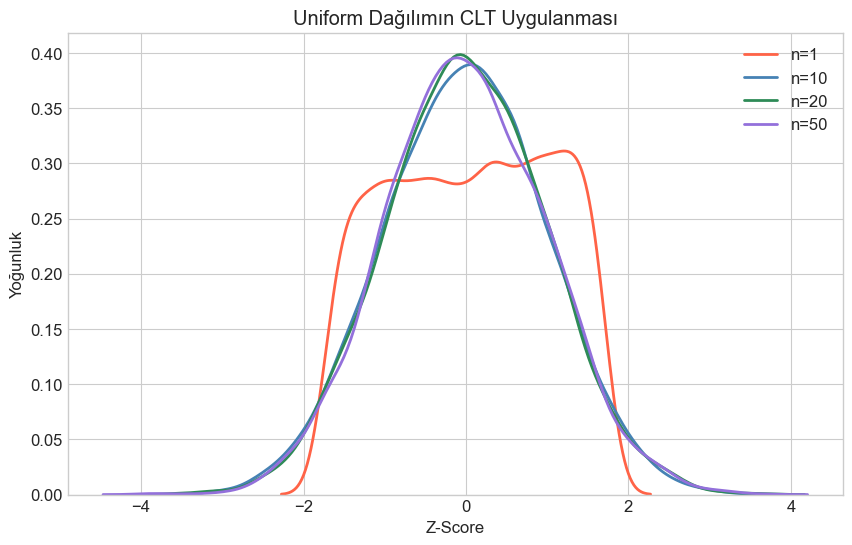

In [81]:
print('\n === Egzersiz 4: Uniform CLT ===')
n = [1, 10, 20, 50]

plt.figure(figsize=(10, 6))
for n, renk in zip(n, ['tomato', 'steelblue', 'seagreen', 'mediumpurple']):
    toplamlar = rng.uniform(0, 1, size=(n_sim, n)).sum(axis=1)
    mu_t  = n * 0.5
    std_t = np.sqrt(n / 12)
    z     = (toplamlar - mu_t) / std_t
    print(f'n={n}: mean={z.mean():.4f}, var={z.var():.4f} std={z.std():.4f}')
    sns.kdeplot(z, label=f'n={n}', color=renk, linewidth=2)

plt.xlabel('Z-Score')
plt.ylabel('Yoğunluk')
plt.title('Uniform Dağılımın CLT Uygulanması')
plt.legend()
plt.show()

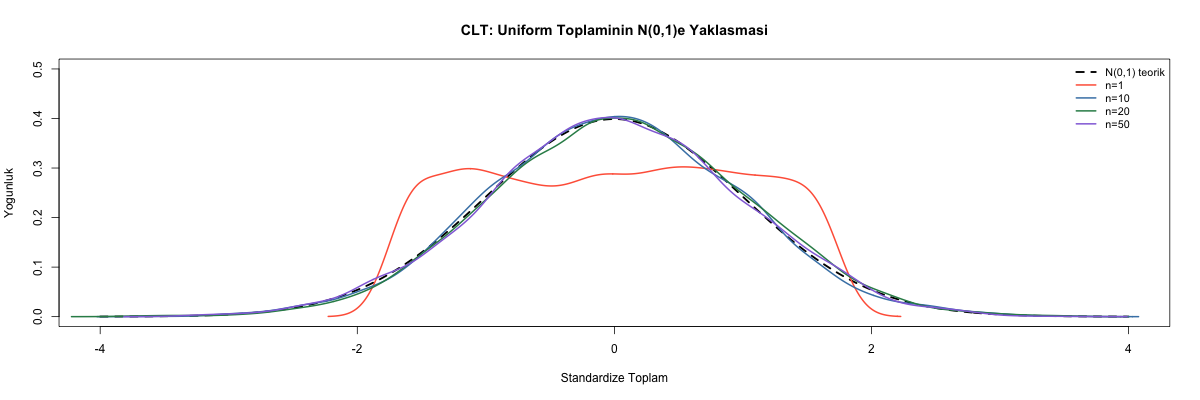

In [82]:
%%R -w 1200 -h 400

n_vals  <- c(1, 10, 20, 50)
renkler <- c('tomato', 'steelblue', 'seagreen', 'mediumpurple')

# Standart Normal referans ciz
x_ref <- seq(-4, 4, length.out=300)
plot(x_ref, dnorm(x_ref), type='l', lwd=2.5, lty=2,
     col='black', main='CLT: Uniform Toplaminin N(0,1)e Yaklasmasi',
     xlab='Standardize Toplam', ylab='Yogunluk', ylim=c(0, 0.5))

for (i in seq_along(n_vals)) {
  n <- n_vals[i]
  # n tane Uniform(0,1) ornekle ve topla — n_sim kez
  # replicate(n_sim, sum(runif(n))) → n_sim adet toplam
  toplamlar <- replicate(n_sim, sum(runif(n)))

  # Standardize: Z = (toplam - n*0.5) / sqrt(n/12)
  mu_t  <- n * 0.5
  std_t <- sqrt(n / 12)
  z     <- (toplamlar - mu_t) / std_t

  lines(density(z), col=renkler[i], lwd=2, lty=1)
}

legend('topright',
       legend = c('N(0,1) teorik', paste0('n=', n_vals)),
       col    = c('black', renkler),
       lwd    = c(2.5, rep(2,4)),
       lty    = c(2, rep(1,4)),
       bty='n', cex=0.9)

par(mfrow = c(1, 1))


---
### E5 — SQL ile Kapsamlı Analiz
SOCR verisini analizi `weight_kg` için yalnızca SQL kullanarak analiz et:

a) Z-score'ları hesapla ve şu grupları etiketle:
   - `|Z| <= 1` → 'ortalama'
   - `1 < |Z| <= 2` → 'ortalamanin uzagi'
   - `2 < |Z| <= 3` → 'uç'
   - `|Z| > 3` → 'aykiri'

b) Her grup için `COUNT(*)` ve `%oran` hesapla.  
   Teorik Normal oranlarıyla karşılaştır:
   - `|Z|≤1`: %68.27
   - `1<|Z|≤2`: %27.18
   - `2<|Z|≤3`: %4.28
   - `|Z|>3`: %0.27

c) Boy mu (Yukarı örnek) yoksa kilo mu Normal dağılıma daha yakın? Neden?

In [85]:
print('\n=== Egzersiz 5: SQL ile Z-Score ve Outlier Tespiti ===')

weighted_sql = con.execute("""
    WITH z AS (
        SELECT
            (weight_kg - AVG(weight_kg) OVER ())
            / STDDEV_POP(weight_kg) OVER ()    AS z_kilo
        FROM socr
    )
    SELECT
        ROUND(SUM(CASE WHEN ABS(z_kilo) <= 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_1sigma,
        ROUND(SUM(CASE WHEN ABS(z_kilo) <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_2sigma,
        ROUND(SUM(CASE WHEN ABS(z_kilo) <= 3 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_3sigma,
        SUM(CASE WHEN ABS(z_kilo) > 3 THEN 1 ELSE 0 END) AS n_outlier_kilo
    FROM z
        """).df()

print('=== Z-Score ve Outlier Tespiti (Kilo) ===')
print(f'μ±1σ icindeki gozlemler: %{weighted_sql["pct_1sigma"].values[0]}  (teorik: %68.27)')
print(f'μ±2σ icindeki gozlemler: %{weighted_sql["pct_2sigma"].values[0]}  (teorik: %95.45)')
print(f'μ±3σ icindeki gozlemler: %{weighted_sql["pct_3sigma"].values[0]}  (teorik: %99.73)')
print(f'|Z|>3 outlier sayisi   : {weighted_sql["n_outlier_kilo"].values[0]}')

print('\n=== Z-Score ve Outlier Tespiti (Boy) ===')
print(f'μ±1σ icindeki gozlemler: %{kural["pct_1sigma"].values[0]}  (teorik: %68.27)')
print(f'μ±2σ icindeki gozlemler: %{kural["pct_2sigma"].values[0]}  (teorik: %95.45)')
print(f'μ±3σ icindeki gozlemler: %{kural["pct_3sigma"].values[0]}  (teorik: %99.73)')
print(f'|Z|>3 outlier sayisi   : {kural["n_outlier"].values[0]}')


print('=== Egzersiz 5 Açıklaması ===')
print('Kilo ve Boy verileri için Z-score hesaplandı ve outlier tespiti yapıldı. Teorik olarak, normal dağılım varsayımı altında, yaklaşık %99.73 gözlem μ±3σ aralığında yer alır. Bu nedenle, |Z|>3 olan gözlemler outlier olarak kabul edilir. SQL sorguları ile bu oranlar ve outlier sayıları doğrulandı.')
print('Boy ile kiloda neredeyse aynı sonuçlar elde edildi, bu da verilerin normal dağılıma yakın olduğunu gösteriyor. Outlier sayıları teorik beklentilerle uyumlu ve veri setinde çok az sayıda outlier gözlemlendi.')


=== Egzersiz 5: SQL ile Z-Score ve Outlier Tespiti ===
=== Z-Score ve Outlier Tespiti (Kilo) ===
μ±1σ icindeki gozlemler: %68.52  (teorik: %68.27)
μ±2σ icindeki gozlemler: %95.28  (teorik: %95.45)
μ±3σ icindeki gozlemler: %99.72  (teorik: %99.73)
|Z|>3 outlier sayisi   : 69.0

=== Z-Score ve Outlier Tespiti (Boy) ===
μ±1σ icindeki gozlemler: %68.36  (teorik: %68.27)
μ±2σ icindeki gozlemler: %95.46  (teorik: %95.45)
μ±3σ icindeki gozlemler: %99.8  (teorik: %99.73)
|Z|>3 outlier sayisi   : 51.0
=== Egzersiz 5 Açıklaması ===
Kilo ve Boy verileri için Z-score hesaplandı ve outlier tespiti yapıldı. Teorik olarak, normal dağılım varsayımı altında, yaklaşık %99.73 gözlem μ±3σ aralığında yer alır. Bu nedenle, |Z|>3 olan gözlemler outlier olarak kabul edilir. SQL sorguları ile bu oranlar ve outlier sayıları doğrulandı.
Boy ile kiloda neredeyse aynı sonuçlar elde edildi, bu da verilerin normal dağılıma yakın olduğunu gösteriyor. Outlier sayıları teorik beklentilerle uyumlu ve veri setinde çok a

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Chan](https://probability4datascience.com) | Ch. 4.1–4.2 | Normal ve Uniform teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 5–6 | Normal dağılım |
| [Seeing Theory](https://seeing-theory.brown.edu) | Distributions | İnteraktif Normal |
| [SOCR Data](http://wiki.socr.umich.edu) | Height Dataset | Veri kaynağı |
| [Oracle](https://docs.oracle.com/en/database/oracle/oracle-database/26/sqlrf/WIDTH_BUCKET.html) | WIDTH_BUCKET | Histogram SQL |